In [14]:
import numpy as np 
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn 
import torch.nn.functional as F

In [15]:
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset , DataLoader

# ---------------------------
# 1. LOAD MNIST DATA
# ---------------------------
transform = transforms.ToTensor()

mnist_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# convert to tensors
X = mnist_data.data.float()   # (60000, 28, 28)
X = X.unsqueeze(1)
y = mnist_data.targets        # (60000,)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=101)

train_data = TensorDataset(X_train, y_train)
test_data  = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, drop_last=True)
test_loader  = DataLoader(test_data, batch_size=len(test_data), shuffle=False)

In [16]:
class CNNmodel(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 10, kernel_size=3, stride=1, padding=1)
        self.bn1   = nn.BatchNorm2d(10)

        self.conv2 = nn.Conv2d(10, 20, kernel_size=3, stride=1, padding=1)
        self.bn2   = nn.BatchNorm2d(20)

        self.fc1 = nn.Linear(20 * 7 * 7, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)

        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))   # 🔥 you were missing this earlier
        x = self.fc2(x)

        return x

In [17]:
model=CNNmodel()
lossfn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(), lr=0.05)



In [18]:
# a function that trains the model

def function2trainTheModel(model , lossfn , optimizer):

  # number of epochs
  numepochs = 10

  # initialize losses
  losses    = torch.zeros(numepochs)
  trainAcc  = []
  testAcc   = []


  # loop over epochs
  for epochi in range(numepochs):

    # loop over training data batches
    model.train()
    batchAcc  = []
    batchLoss = []
    for X,y in train_loader:

      # forward pass and loss
      yHat = model(X)
      loss = lossfn(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss from this batch
      batchLoss.append(loss.item())

      # compute accuracy
      matches = torch.argmax(yHat,axis=1) == y     # booleans (false/true)
      matchesNumeric = matches.float()             # convert to numbers (0/1)
      accuracyPct = 100*torch.mean(matchesNumeric) # average and x100
      batchAcc.append( accuracyPct )               # add to list of accuracies
    # end of batch loop...

    # now that we've trained through the batches, get their average training accuracy
    trainAcc.append( np.mean(batchAcc) )

    # and get average losses across the batches
    losses[epochi] = np.mean(batchLoss)

    # test accuracy
    model.eval()
    X,y = next(iter(test_loader)) # extract X,y from test dataloader
    with torch.no_grad(): # deactivates autograd
      yHat = model(X)

    # compare the following really long line of code to the training accuracy lines
    testAcc.append( 100*torch.mean((torch.argmax(yHat,axis=1)==y).float()) )

  # end epochs

  # function output
  return trainAcc,testAcc,losses


In [19]:
trainAcc,testAcc,losses=function2trainTheModel(model , lossfn , optimizer)

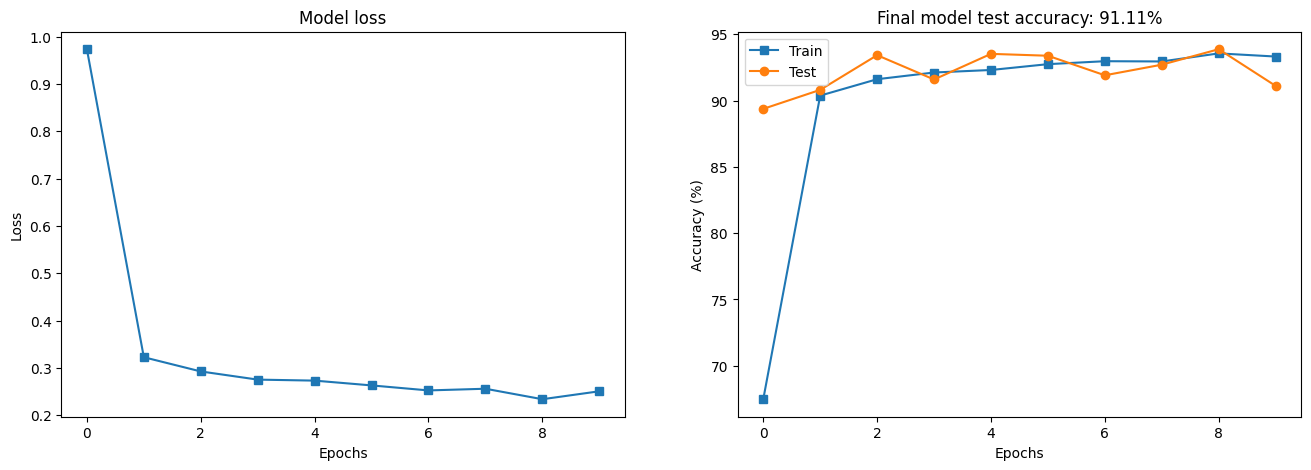

In [20]:
fig,ax = plt.subplots(1,2,figsize=(16,5))

ax[0].plot(losses,'s-')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Model loss')

ax[1].plot(trainAcc,'s-',label='Train')
ax[1].plot(testAcc,'o-',label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title(f'Final model test accuracy: {testAcc[-1]:.2f}%')
ax[1].legend()

plt.show()